## Extract data from NEXTGEMs FESOM

### FESOM IFS_4.4-FESOM_5-cycle3 Next Gems

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pylab as plt
import matplotlib.cm as cm
import cmocean.cm as cmo
import gribscan
import intake
from scipy.interpolate import griddata
import xoak

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xoak/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


### Mesh

In [2]:
ds_mesh = xr.open_dataset('mesh_NG/IFS_4.4-FESOM_5-cycle3_mesh.nc')
ds_mesh

<xarray.Dataset> Size: 885MB
Dimensions:           (nod2: 7402886, n3: 3, elem: 14741520, nz: 70, nz1: 70)
Coordinates:
  * nod2              (nod2) int64 59MB 1 2 3 4 ... 7402884 7402885 7402886
  * elem              (elem) int64 118MB 1 2 3 4 ... 14741518 14741519 14741520
  * n3                (n3) int64 24B 0 1 2
  * nz                (nz) int64 560B 0 5 10 15 20 ... 5150 5400 5650 6000 6350
  * nz1               (nz1) float64 560B 2.5 7.5 12.5 ... 6.175e+03 6.175e+03
    elem_center_lons  (elem) float64 118MB ...
    elem_center_lats  (elem) float64 118MB ...
Data variables:
    lat               (nod2) float64 59MB ...
    lon               (nod2) float64 59MB ...
    face_nodes        (n3, elem) int64 354MB ...

In [125]:
lon = ds_mesh.lon.data
np.diff(lon)

array([-0.06135808, -0.00476683, -0.16767479, ...,  0.00592442,
       -0.20924267, -0.00100141], shape=(7402885,))

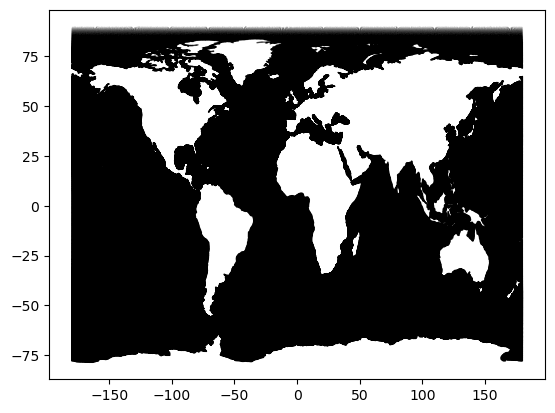

In [3]:
plt.scatter(ds_mesh['elem_center_lons'], ds_mesh['elem_center_lats'], s=1, alpha=0.05, edgecolor="none", facecolor="k")

### Xoak search and interpolation

In [4]:
from dask.distributed import Client
c=Client(n_workers = 3, threads_per_worker = 3)
c

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 3
Total threads: 9,Total memory: 50.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33047,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33811,Total threads: 3
Dashboard: http://127.0.0.1:37301/status,Memory: 16.67 GiB
Nanny: tcp://127.0.0.1:44929,


2025-09-03 15:17:34,313 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:37625 (pid=3221186) exceeded 95% memory budget. Restarting...
2025-09-03 15:17:35,534 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:37625' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('getitem-3badd9a4427524c3890961ecb5ecc4c9', 0, 23, 0, 0), ('getitem-3badd9a4427524c3890961ecb5ecc4c9', 0, 35, 0, 0), ('getitem-3badd9a4427524c3890961ecb5ecc4c9', 0, 13, 0, 0), ('getitem-3badd9a4427524c3890961ecb5ecc4c9', 0, 1, 0, 0), ('getitem-3badd9a4427524c3890961ecb5ecc4c9', 0, 70, 0, 0), ('getitem-3badd9a4427524c3890961ecb5ecc4c9', 0, 57, 0, 0), ('getitem-3badd9a4427524c3890961ecb5ecc4c9', 0, 34, 0, 0), ('getitem-3badd9a4427524c3890961ecb5ecc4c9', 0, 58, 0, 0), ('getitem-3badd9a4427524c3890961ecb5ecc4c9', 0, 69, 0, 0), ('getitem-3badd9a4427524c3890961ecb5ecc4c9', 0, 59, 0, 0), ('getitem-3badd9a4427524c3890961ecb5ecc4c9', 0, 47, 0, 0), ('getitem-3bad

In [ ]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

In [5]:
ds_mesh.xoak.set_index(["elem_center_lats", "elem_center_lons"], "sklearn_geo_balltree")

## Matching resolution to copernicus of 1/12 degrees with nearest neighbor interpolation 
grid_lon = xr.DataArray(np.linspace(-180, 180, 360*12), dims=("grid_lon", ))
grid_lat = xr.DataArray(np.linspace(-90, 90, 180*12), dims=("grid_lat", ))

target_lon, target_lat = xr.broadcast(grid_lon, grid_lat)

grid_elems = ds_mesh.xoak.sel(
    elem_center_lats=target_lat,
    elem_center_lons=target_lon,
).elem

grid_elems = grid_elems.assign_coords(
    target_lat=target_lat,
    target_lon=target_lon,
)

grid_elems = grid_elems.assign_coords(
    grid_lat=grid_lat,
    grid_lon=grid_lon,
)

grid_elems

<xarray.DataArray 'elem' (grid_lon: 4320, grid_lat: 2160)> Size: 75MB
array([[  59748,   59748,   59748, ..., 5291594, 5310793, 5780576],
       [  59748,   59748,   59748, ..., 5291594, 5310793, 5780576],
       [  59748,   59748,   59748, ..., 5291594, 5310793, 5780576],
       ...,
       [  59748,   59748,   59748, ..., 5291594, 5310793, 5780576],
       [  59748,   59748,   59748, ..., 5291594, 5310793, 5780576],
       [  59748,   59748,   59748, ..., 5291594, 5310793, 5780576]],
      shape=(4320, 2160))
Coordinates:
    elem              (grid_lon, grid_lat) int64 75MB 59748 59748 ... 5780576
    elem_center_lons  (grid_lon, grid_lat) float64 75MB -163.7 -163.7 ... -162.4
    elem_center_lats  (grid_lon, grid_lat) float64 75MB -78.6 -78.6 ... 89.97
    target_lat        (grid_lon, grid_lat) float64 75MB -90.0 -89.92 ... 90.0
    target_lon        (grid_lon, grid_lat) float64 75MB -180.0 -180.0 ... 180.0
  * grid_lat          (grid_lat) float64 17kB -90.0 -89.92 -89.83 ... 89.92 90.0
  * grid_lon          (grid_lon) float64 35kB -180.0 -179.9 ... 179.9 180.0

In [6]:
ds_mesh = ds_mesh.assign_coords(
        lat=("nod2", ds_mesh.lat.data.flatten()),
        lon=("nod2", ds_mesh.lon.data.flatten()),
    )
    # Ensure the xoak index 
ds_mesh.xoak.set_index(["lat", "lon"], "sklearn_geo_balltree")

#-------------get the nod2grids
grid_nodes = ds_mesh.xoak.sel(
        lat = target_lat,
        lon = target_lon,
    ).nod2
grid_nodes

<xarray.DataArray 'nod2' (grid_lon: 4320, grid_lat: 2160)> Size: 75MB
array([[  29590,   29590,   29590, ..., 2648172, 4497064, 2897521],
       [  29590,   29590,   29590, ..., 2648172, 4497064, 2897521],
       [  29590,   29590,   29590, ..., 2648172, 4497064, 2897521],
       ...,
       [  29590,   29590,   29590, ..., 2648172, 4497064, 2897521],
       [  29590,   29590,   29590, ..., 2648172, 4497064, 2897521],
       [  29590,   29590,   29590, ..., 2648172, 4497064, 2897521]],
      shape=(4320, 2160))
Coordinates:
    lat      (grid_lon, grid_lat) float64 75MB -78.62 -78.62 ... 89.9 89.99
    lon      (grid_lon, grid_lat) float64 75MB -163.6 -163.6 ... 171.4 -48.1
    nod2     (grid_lon, grid_lat) int64 75MB 29590 29590 ... 4497064 2897521
Dimensions without coordinates: grid_lon, grid_lat

### Creating the land mask

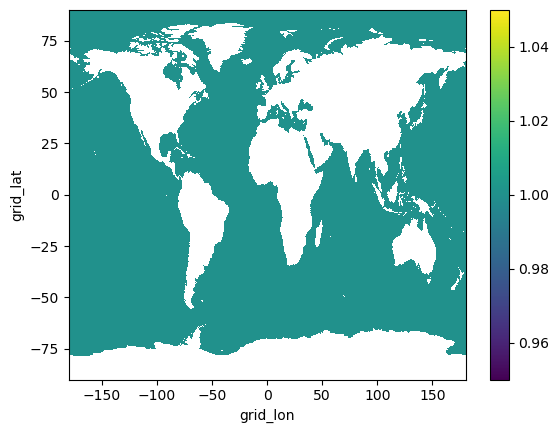

In [7]:
def haversine(lon1, lat1, lon2, lat2):
    """Great-circle distance in km."""
    R = 6371  # Earth radius in km
    dlon = np.deg2rad(lon2 - lon1)
    dlat = np.deg2rad(lat2 - lat1)
    a = np.sin(dlat/2)**2 + np.cos(np.deg2rad(lat1)) * np.cos(np.deg2rad(lat2)) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# Compute distances
dist = haversine(
    grid_elems.target_lon, grid_elems.target_lat,
    grid_elems.elem_center_lons, grid_elems.elem_center_lats
)

# Create mask (tune threshold; ~20-100 km typical for FESOM)
threshold = 9  # km
masknan = xr.where(dist < threshold, 1, np.nan)
masknan.plot(x='grid_lon')

In [10]:
# grid_elems.to_netcdf('grid_elems_pre.nc')
# grid_nodes.to_netcdf('grid_nodes_pre.nc')
# masknan.to_netcdf('mask_nan_pre.nc')

### Import data from NEXTGEMS

In [11]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")

In [83]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="zarr.core.metadata.v2")

ds = cat.FESOM["IFS_4.4-FESOM_5-cycle3"]["3D_daily_native"].reader.read(
    engine="netcdf4",
    chunks={
    "time": -1,     # 1 month per chunk
    "nz1": 1,      # vertical levels (e.g., 10 levels per chunk)
    "elem": -1,  # coming from ncdump -hs /work/bm1235/a270046/cycle3/tco2559l137/hzfy/hres/intel.levante.openmpi/lvt.intel.sp/Cycle3_012020/u.fesom.2020.nc
    },
)
ds = ds[['u', 'v', 'w','salt']]
ds

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/intake/readers/readers.py:1313: UserWarning: The specified chunks separate the stored chunks along dimension "nz1" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return open_mfdataset(ofs, **kw)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/intake/readers/readers.py:1313: UserWarning: The specified chunks separate the stored chunks along dimension "nz1" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return open_mfdataset(ofs, **kw)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/intake/readers/readers.py:1313: UserWarning: The specified chunks separate the stored chunks along dimension "nz1" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return open_mfdataset(ofs, **kw)
/work/bk1450/b383184/conda/envs/pa

<xarray.Dataset> Size: 22TB
Dimensions:  (time: 1808, nz1: 69, elem: 14741520, nz: 70, nod2: 7402886)
Coordinates:
    lon      (nod2) float64 59MB dask.array<chunksize=(7402886,), meta=np.ndarray>
    lat      (nod2) float64 59MB dask.array<chunksize=(7402886,), meta=np.ndarray>
  * nz       (nz) float64 560B 0.0 5.0 10.0 15.0 ... 5.65e+03 6e+03 6.35e+03
  * time     (time) datetime64[ns] 14kB 2020-01-20T23:56:00 ... 2024-12-31T23...
  * nz1      (nz1) float64 552B 2.5 7.5 12.5 ... 5.525e+03 5.825e+03 6.175e+03
Dimensions without coordinates: elem, nod2
Data variables:
    u        (time, nz1, elem) float32 7TB dask.array<chunksize=(12, 1, 14741520), meta=np.ndarray>
    v        (time, nz1, elem) float32 7TB dask.array<chunksize=(12, 1, 14741520), meta=np.ndarray>
    w        (time, nz, nod2) float32 4TB dask.array<chunksize=(12, 2, 321865), meta=np.ndarray>
    salt     (time, nz1, nod2) float32 4TB dask.array<chunksize=(12, 1, 321865), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    history:      2022-03-19 08:26:17 GMT; Grid description file generated wi...

### Select the dates

In [84]:
ds = ds.sel(time=slice(None,'2020-01'))
ds

<xarray.Dataset> Size: 147GB
Dimensions:  (time: 12, nz1: 69, elem: 14741520, nz: 70, nod2: 7402886)
Coordinates:
    lon      (nod2) float64 59MB dask.array<chunksize=(7402886,), meta=np.ndarray>
    lat      (nod2) float64 59MB dask.array<chunksize=(7402886,), meta=np.ndarray>
  * nz       (nz) float64 560B 0.0 5.0 10.0 15.0 ... 5.65e+03 6e+03 6.35e+03
  * time     (time) datetime64[ns] 96B 2020-01-20T23:56:00 ... 2020-01-31T23:...
  * nz1      (nz1) float64 552B 2.5 7.5 12.5 ... 5.525e+03 5.825e+03 6.175e+03
Dimensions without coordinates: elem, nod2
Data variables:
    u        (time, nz1, elem) float32 49GB dask.array<chunksize=(12, 1, 14741520), meta=np.ndarray>
    v        (time, nz1, elem) float32 49GB dask.array<chunksize=(12, 1, 14741520), meta=np.ndarray>
    w        (time, nz, nod2) float32 25GB dask.array<chunksize=(12, 2, 321865), meta=np.ndarray>
    salt     (time, nz1, nod2) float32 25GB dask.array<chunksize=(12, 1, 321865), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    history:      2022-03-19 08:26:17 GMT; Grid description file generated wi...

### The Z levels

In [85]:
za = ds_mesh.nz.values #70
zb = ds_mesh.nz1.values #69

zc = np.array(sorted(np.concatenate((za, zb))))
#print(zc)

zg = np.sort(np.hstack((0.5 * (zc[0:-1] + zc[1:]), zc)))

#nz grid 
nz_grid = ds_mesh.sel(nz = zg, method = 'nearest').nz
print(nz_grid.astype(int))

ds_mesh['nz1'] = np.unique(ds_mesh.nz1)
nz1_grid = ds_mesh.sel(nz1 = zg, method = 'nearest').nz1
print(nz1_grid.astype(int))

<xarray.DataArray 'nz' (nz: 277)> Size: 2kB
array([   0,    0,    5,    5,    5,    5,   10,   10,   10,   10,   15,
         15,   15,   15,   20,   20,   20,   20,   25,   25,   25,   25,
         30,   30,   30,   30,   35,   35,   35,   35,   40,   40,   40,
         40,   45,   45,   45,   45,   50,   50,   50,   50,   55,   55,
         55,   55,   60,   60,   60,   60,   65,   65,   65,   65,   70,
         70,   70,   70,   75,   75,   75,   75,   80,   80,   80,   80,
         85,   85,   85,   85,   90,   90,   90,   90,   95,   95,   95,
         95,  100,  100,  100,  100,  110,  110,  110,  110,  120,  120,
        120,  120,  130,  130,  130,  130,  140,  140,  140,  140,  150,
        150,  150,  150,  160,  160,  160,  160,  170,  170,  170,  170,
        180,  180,  180,  180,  190,  190,  190,  190,  200,  200,  200,
        200,  220,  220,  220,  220,  240,  240,  240,  240,  260,  260,
        260,  260,  280,  280,  280,  280,  300,  300,  300,  300,  340,
       

In [86]:
z_target = xr.DataArray(
    sorted(list(ds_mesh.nz1.data) + list(ds_mesh.nz.data[[0,-1]])),
    dims = 'z',)
z_target

<xarray.DataArray (z: 71)> Size: 568B
array([0.000e+00, 2.500e+00, 7.500e+00, 1.250e+01, 1.750e+01, 2.250e+01,
       2.750e+01, 3.250e+01, 3.750e+01, 4.250e+01, 4.750e+01, 5.250e+01,
       5.750e+01, 6.250e+01, 6.750e+01, 7.250e+01, 7.750e+01, 8.250e+01,
       8.750e+01, 9.250e+01, 9.750e+01, 1.050e+02, 1.150e+02, 1.250e+02,
       1.350e+02, 1.450e+02, 1.550e+02, 1.650e+02, 1.750e+02, 1.850e+02,
       1.950e+02, 2.100e+02, 2.300e+02, 2.500e+02, 2.700e+02, 2.900e+02,
       3.200e+02, 3.600e+02, 4.000e+02, 4.400e+02, 4.800e+02, 5.200e+02,
       5.600e+02, 6.000e+02, 6.400e+02, 7.100e+02, 8.100e+02, 9.500e+02,
       1.110e+03, 1.255e+03, 1.415e+03, 1.600e+03, 1.810e+03, 2.035e+03,
       2.275e+03, 2.525e+03, 2.775e+03, 3.025e+03, 3.275e+03, 3.525e+03,
       3.775e+03, 4.025e+03, 4.275e+03, 4.525e+03, 4.775e+03, 5.025e+03,
       5.275e+03, 5.525e+03, 5.825e+03, 6.175e+03, 6.350e+03])
Dimensions without coordinates: z

In [87]:
U_grid = ds.u.isel(elem=grid_elems - 1).sel(nz1=z_target,method = 'nearest')
V_grid = ds.v.isel(elem=grid_elems - 1).sel(nz1=z_target,method = 'nearest')
W_grid = ds.w.isel(nod2=grid_nodes - 1).sel(nz=z_target,method = 'nearest')

W_grid

<xarray.DataArray 'w' (time: 12, z: 71, grid_lon: 4320, grid_lat: 2160)> Size: 32GB
dask.array<getitem, shape=(12, 71, 4320, 2160), dtype=float32, chunksize=(12, 2, 149, 2160), chunktype=numpy.ndarray>
Coordinates:
    lon      (grid_lon, grid_lat) float64 75MB dask.array<chunksize=(3427, 2160), meta=np.ndarray>
    lat      (grid_lon, grid_lat) float64 75MB dask.array<chunksize=(3427, 2160), meta=np.ndarray>
    nz       (z) float64 568B 0.0 5.0 10.0 15.0 ... 6e+03 6.35e+03 6.35e+03
  * time     (time) datetime64[ns] 96B 2020-01-20T23:56:00 ... 2020-01-31T23:...
    nod2     (grid_lon, grid_lat) int64 75MB 29590 29590 ... 4497064 2897521
Dimensions without coordinates: z, grid_lon, grid_lat
Attributes:
    description:  vertical velocity
    long_name:    vertical velocity
    units:        m/s

In [96]:
w_interp=W_grid.assign_coords(
    grid_lon = target_lon.isel(grid_lat = 0, drop = True),
    grid_lat = target_lat.isel(grid_lon = 0, drop = True),
    z = z_target,
    )

u_interp=U_grid.assign_coords(
    grid_lon = target_lon.isel(grid_lat = 0, drop = True),
    grid_lat = target_lat.isel(grid_lon = 0, drop = True),
    z = z_target,
    )
v_interp=V_grid.assign_coords(
    grid_lon = target_lon.isel(grid_lat = 0, drop = True),
    grid_lat = target_lat.isel(grid_lon = 0, drop = True),
    z = z_target,
    )

u_interp= u_interp.rename({'nz1':'nz'})
v_interp= v_interp.rename({'nz1':'nz'})

w_interp=w_interp.transpose('time','z','grid_lat','grid_lon')
v_interp=v_interp.transpose('time','z','grid_lat','grid_lon')
w_interp=w_interp.transpose('time','z','grid_lat','grid_lon')

w = (w_interp*masknan).sel(grid_lat=slice(-50,50),grid_lon=slice(-100,0))
u = (u_interp*masknan).sel(grid_lat=slice(-50,50),grid_lon=slice(-100,0))
v = (v_interp*masknan).sel(grid_lat=slice(-50,50),grid_lon=slice(-100,0))

u

<xarray.DataArray (time: 12, z: 71, grid_lon: 1200, grid_lat: 1200)> Size: 10GB
dask.array<getitem, shape=(12, 71, 1200, 1200), dtype=float64, chunksize=(12, 1, 1200, 1200), chunktype=numpy.ndarray>
Coordinates:
  * time              (time) datetime64[ns] 96B 2020-01-20T23:56:00 ... 2020-...
    nz                (z) float64 568B 2.5 2.5 7.5 ... 6.175e+03 6.175e+03
    elem              (grid_lon, grid_lat) int64 12MB 1278400 ... 6320113
    elem_center_lons  (grid_lon, grid_lat) float64 12MB -99.95 ... -0.04522
    elem_center_lats  (grid_lon, grid_lat) float64 12MB -49.99 -49.91 ... 50.0
    target_lat        (grid_lon, grid_lat) float64 12MB -49.98 -49.9 ... 49.98
    target_lon        (grid_lon, grid_lat) float64 12MB -99.98 ... -0.04168
  * grid_lon          (grid_lon) float64 10kB -99.98 -99.9 ... -0.125 -0.04168
  * grid_lat          (grid_lat) float64 10kB -49.98 -49.9 -49.81 ... 49.9 49.98
  * z                 (z) float64 568B 0.0 2.5 7.5 ... 6.175e+03 6.35e+03

In [161]:
u.drop_vars({'elem_center_lons','elem_center_lats','elem','target_lat','target_lon'}).drop_encoding().rename('u').to_netcdf('u_FESOM.nc')
v.drop_vars({'elem_center_lons','elem_center_lats','elem','target_lat','target_lon'}).drop_encoding().rename('v').to_netcdf('v_FESOM.nc')
w.drop_vars({'elem_center_lons','elem_center_lats','elem','lon','lat','nod2','target_lat','target_lon'}).drop_encoding().rename('w').to_netcdf('w_FESOM.nc')

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 4.87 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 4.87 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sendin

In [160]:
u.drop_vars({'elem_center_lons','elem_center_lats','elem','target_lat','target_lon'}).drop_encoding().rename('u')

<xarray.DataArray 'u' (time: 12, z: 71, grid_lon: 1200, grid_lat: 1200)> Size: 10GB
dask.array<getitem, shape=(12, 71, 1200, 1200), dtype=float64, chunksize=(12, 1, 1200, 1200), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) datetime64[ns] 96B 2020-01-20T23:56:00 ... 2020-01-31T23...
    nz        (z) float64 568B 2.5 2.5 7.5 ... 5.825e+03 6.175e+03 6.175e+03
  * grid_lon  (grid_lon) float64 10kB -99.98 -99.9 -99.81 ... -0.125 -0.04168
  * grid_lat  (grid_lat) float64 10kB -49.98 -49.9 -49.81 ... 49.81 49.9 49.98
  * z         (z) float64 568B 0.0 2.5 7.5 12.5 ... 5.825e+03 6.175e+03 6.35e+03

### Plot

In [108]:
num_particles = 10000

lon = -48.9 * np.ones(shape=(num_particles, ))
lat = np.linspace(1.5, -1, num_particles)

# 1. Center
lon0 = lon.mean()
lat0 = lat.mean()

# 2. Centered coordinates
x = lon - lon0
y = lat - lat0

# 3. Rotation
theta = np.deg2rad(45)
x_rot = x * np.cos(theta) - y * np.sin(theta)
y_rot = x * np.sin(theta) + y * np.cos(theta)

# 4. Back to lon/lat
lon_start = x_rot + lon0
lat_start = y_rot + lat0

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 9.73 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


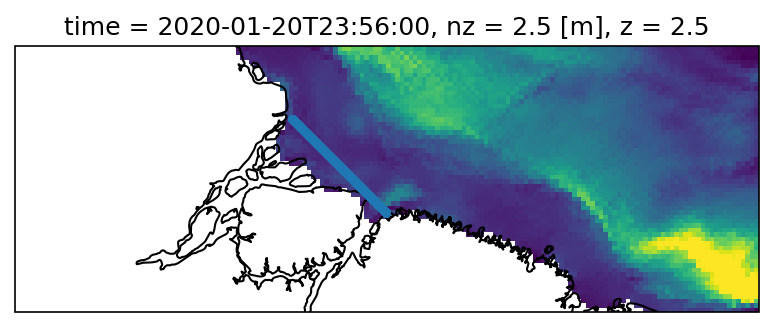

In [127]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt



da = (v.isel(time=0, z=1).sel(grid_lon=slice(-75, -35), 
                              grid_lat=slice(-10, 30))**2 + u.isel(time=0, z=1).sel(grid_lon=slice(-75, -35), grid_lat=slice(-10, 30))**2)**0.5

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
)
fig.set_dpi(150)

ax.plot(lon_start,lat_start,marker='.')
# xarray will use lon/lat coords for x/y; no transform needed here
mappable = da.plot(
    x='grid_lon', y='grid_lat',
    ax=ax, add_colorbar=False,robust=True,
)

ax.coastlines()
ax.set_extent([-55, -41, -2.5, 2.5], crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.show()

In [128]:
import numpy as np

def haversine_deg(lon1, lat1, lon2, lat2, R=6371000.0):
    # degrees to radians
    lon1 = np.deg2rad(lon1); lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2); lat2 = np.deg2rad(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

lon = ds_mesh.lon.values
lat = ds_mesh.lat.values
fn  = ds_mesh.face_nodes.values.astype(int) - 1  # 0-based

# corners per element
i0, i1, i2 = fn[...,0], fn[...,1], fn[...,2]
lon0, lat0 = lon[i0], lat[i0]
lon1_,lat1_= lon[i1], lat[i1]
lon2_,lat2_= lon[i2], lat[i2]

# edge lengths (m)
e01 = haversine_deg(lon0, lat0, lon1_, lat1_)
e12 = haversine_deg(lon1_, lat1_, lon2_, lat2_)
e20 = haversine_deg(lon2_, lat2_, lon0, lat0)

edge_med = np.median(np.stack([e01,e12,e20], axis=-1), axis=-1)  # per element
# Equivalent cell diameter (area-based, optional)
def tri_area_spherical(lon,lat,i0,i1,i2,R=6371000.0):
    # planar approx for small triangles
    # convert to meters locally using mean latitude
    lonr = np.deg2rad(lon); latr = np.deg2rad(lat)
    lon0,lat0 = lonr[i0], latr[i0]
    lon1,lat1 = lonr[i1], latr[i1]
    lon2,lat2 = lonr[i2], latr[i2]
    latm = (lat0+lat1+lat2)/3
    x0, y0 = R*np.cos(latm)*lon0, R*lat0
    x1, y1 = R*np.cos(latm)*lon1, R*lat1
    x2, y2 = R*np.cos(latm)*lon2, R*lat2
    return 0.5*np.abs(x0*(y1-y2)+x1*(y2-y0)+x2*(y0-y1))

area = tri_area_spherical(lon,lat,i0,i1,i2)
eq_diam = 2*np.sqrt(area/np.pi)  # meters

# Summaries:
print("Median edge length: %.0f m (%.2f km)" % (np.median(edge_med), np.median(edge_med)/1000))
print("Median equivalent diameter: %.0f m (%.2f km)" % (np.median(eq_diam), np.median(eq_diam)/1000))

Median edge length: 5783 m (5.78 km)
Median equivalent diameter: 2192 m (2.19 km)


### Parcels just because

In [162]:
ufiles = 'u_FESOM.nc'
vfiles = 'v_FESOM.nc'
wfiles = 'w_FESOM.nc'

In [163]:
from parcels import ParticleSet
from parcels import JITParticle
from parcels import AdvectionRK4_3D
from parcels import AdvectionRK4
from parcels import Variable
from datetime import timedelta
from parcels import FieldSet

In [170]:
## parameters

## set the tracking time
days = 10
minutes = 20

## record the particles every timestep of
hours=6

## define the fieldset
filenames = {"U": ufiles,
             "V": vfiles,
             "W": wfiles,
            }

variables = {"U": "u",
             "V": "v",
             "W": "w",}

dimensions = {'time': 'time',
              'depth': 'z',
              'lat': 'grid_lat',
              'lon': 'grid_lon'}


## now the fieldset
fieldset = FieldSet.from_netcdf(
    filenames,
    variables,
    dimensions,
)

##check the error
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

## Time and depth initial conditios
time_origin=np.array([str(fieldset.time_origin)],dtype='datetime64[ns]')
time = np.repeat(time_origin, num_particles)  # Assign the same time to all particles
depth = np.random.uniform(0,10, size=num_particles)  # Choose random depths

# initiate pset
pset = ParticleSet(
    fieldset=fieldset,
    lon = lon_start,
    lat = lat_start,
    depth=depth,
    time=time
) 

rnd=str(np.random.randint(1234))

out_path = '/work/bk1450/b383184/Amazon/NextGEMS/' #path to store the particle zarr
out_fn = 'Parcels_run_'+rnd

output_file = pset.ParticleFile(name=out_path+out_fn, 
                                outputdt=timedelta(hours=hours))

In [171]:
## Execute particles
pset.execute(
    [AdvectionRK4_3D,CheckError],
    runtime=timedelta(days=days),
    dt=timedelta(minutes=minutes),
    output_file= output_file
)

INFO: Output files are stored in /work/bk1450/b383184/Amazon/NextGEMS/Parcels_run_193.zarr.

  0%|          | 0/864000.0 [00:00<?, ?it/s]
  0%|          | 1200.0/864000.0 [00:10<2:09:33, 111.00it/s]
  2%|▎         | 21600.0/864000.0 [00:11<05:42, 2458.06it/s]
  5%|▌         | 43200.0/864000.0 [00:13<03:01, 4520.45it/s]
  8%|▊         | 64800.0/864000.0 [00:15<02:10, 6117.08it/s]
 10%|█         | 86400.0/864000.0 [00:26<03:41, 3518.47it/s]
 10%|█         | 87600.0/864000.0 [00:27<03:54, 3304.05it/s]
 12%|█▎        | 108000.0/864000.0 [00:28<02:27, 5140.26it/s]
 15%|█▌        | 129600.0/864000.0 [00:30<01:56, 6302.87it/s]
 15%|█▌        | 130800.0/864000.0 [00:31<02:12, 5540.17it/s]
 18%|█▊        | 151200.0/864000.0 [00:32<01:28, 8019.89it/s]
 20%|██        | 172800.0/864000.0 [00:41<02:43, 4220.89it/s]
 20%|██        | 174000.0/864000.0 [00:42<02:56, 3902.59it/s]
 22%|██▎       | 194400.0/864000.0 [00:43<01:53, 5916.48it/s]
 23%|██▎       | 195600.0/864000.0 [00:44<02:10, 5129.48it/s]


In [3]:
ds_traj = xr.open_zarr('Parcels_run_193.zarr')
ds_traj = ds_traj.compute()
ds_traj

<xarray.Dataset> Size: 8MB
Dimensions:     (trajectory: 10000, obs: 40)
Coordinates:
  * obs         (obs) int32 160B 0 1 2 3 4 5 6 7 8 ... 32 33 34 35 36 37 38 39
  * trajectory  (trajectory) int64 80kB 30000 30001 30002 ... 39997 39998 39999
Data variables:
    lat         (trajectory, obs) float32 2MB 1.134 1.163 ... -0.6715 -0.6632
    lon         (trajectory, obs) float32 2MB -49.78 -49.79 ... -48.02 -48.02
    time        (trajectory, obs) datetime64[ns] 3MB 2020-01-20T23:56:00 ... ...
    z           (trajectory, obs) float32 2MB 9.423 9.206 ... 0.008903 0.01081
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

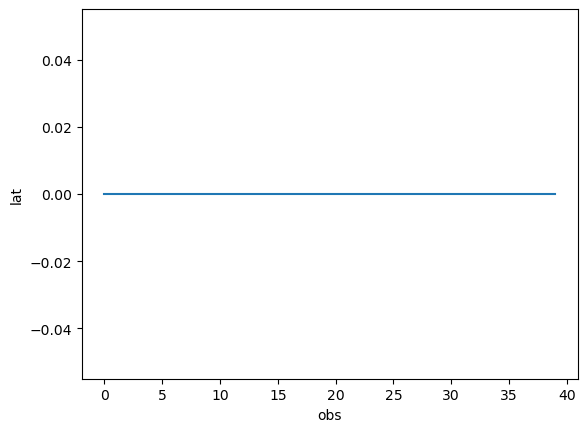

In [4]:
ds_traj.lat.isnull().sum('trajectory').plot(label='FESOM regular')

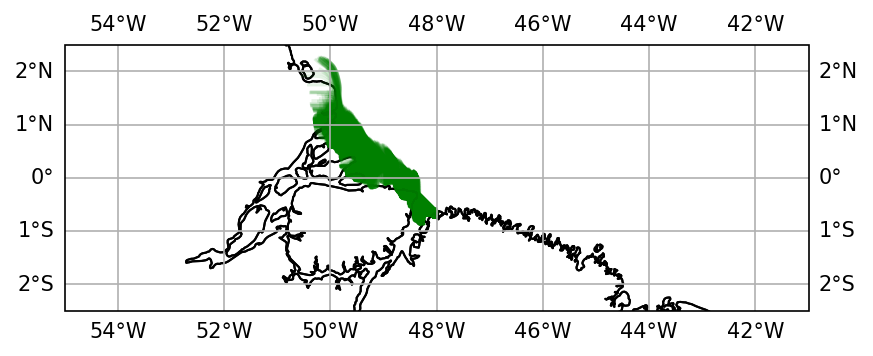

In [6]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
fig.set_dpi(150)

for n in range(ds_traj.sizes["trajectory"]):
    ax.plot(
        *ds_traj.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="g", alpha=0.1,
        transform=ccrs.PlateCarree(),
    )

ax.coastlines()
ax.coastlines()
ax.set_extent([-55, -41, -2.5, 2.5], crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.gridlines(draw_labels=True);